# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 06a — Données de l'univers pairs trading

**Rôle.** On constitue un **univers dédié au pairs trading**, distinct de l'univers momentum (aucun titre commun), pour que les stratégies restent indépendantes et que la comparaison finale soit propre. Cet univers sert au screening de paires cointégrées (notebook 06b).

**Pourquoi un univers séparé.** Sur un desk, les équipes stat-arb (pairs) et momentum ne partagent pas leurs instruments. Réutiliser les mêmes titres corrélerait artificiellement les stratégies et fausserait la comparaison de la Phase 5.

Comme en Phase 0, on **archive** les données téléchargées (`data/pairs_prices_raw.parquet`) pour la reproductibilité : on ne retélécharge plus ensuite.

> À exécuter sur ta machine avec accès Internet (yfinance). Une fois le `.parquet` créé, les exécutions suivantes rechargent le fichier local.


## 1. L'univers (28 titres, 7 secteurs)

Des candidats regroupés par secteur, à fort sens économique (condition d'un pairs trading crédible). Le regroupement sert au filtre secteur du screening : on ne testera que les paires **intra-secteur**.

| Secteur | Tickers |
|---|---|
| Banques | BAC, WFC, C, GS, MS, USB, PNC |
| Pétrole / Énergie | CVX, COP, SLB, EOG, MPC |
| Paiement / Cartes | V, MA, AXP |
| Télécoms | VZ, T, TMUS |
| Distribution / Retail | HD, LOW, TGT, WMT |
| Semi-conducteurs | AMD, INTC, QCOM, TXN |
| Classes d'actions (contrôle) | GOOGL, GOOG |

**GOOGL / GOOG** est un cas de contrôle : deux classes d'actions de la même société, cointégration quasi mécanique. Si le screener ne les classe pas parmi les meilleures paires, c'est qu'il y a un bug. C'est un test de validation de notre pipeline.


In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    import yfinance as yf
except ImportError:
    raise ImportError("Installe yfinance : pip install yfinance")

plt.rcParams["figure.figsize"]=(11,4.5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3
DATA_DIR = "../data"; os.makedirs(DATA_DIR, exist_ok=True)

SECTORS = {
    "Banques":                 ["BAC", "WFC", "C", "GS", "MS", "USB", "PNC"],
    "Petrole_Energie":         ["CVX", "COP", "SLB", "EOG", "MPC"],
    "Paiement_Cartes":         ["V", "MA", "AXP"],
    "Telecoms":                ["VZ", "T", "TMUS"],
    "Distribution_Retail":     ["HD", "LOW", "TGT", "WMT"],
    "Semi_conducteurs":        ["AMD", "INTC", "QCOM", "TXN"],
    "Classes_actions":         ["GOOGL", "GOOG"],
}
PAIRS_TICKERS = sorted({t for v in SECTORS.values() for t in v})

# Sécurité : aucun chevauchement avec l'univers momentum
MOMENTUM = {"AAPL","MSFT","NVDA","AMZN","JPM","XOM","JNJ","PG"}
overlap = MOMENTUM & set(PAIRS_TICKERS)
assert not overlap, f"Chevauchement interdit avec l'univers momentum : {overlap}"
print(f"{len(PAIRS_TICKERS)} titres, aucun chevauchement avec le momentum.")

# Même période que l'univers momentum, pour des tests comparables
START = "2010-01-01"; END = None

28 titres, aucun chevauchement avec le momentum.


## 2. Téléchargement avec archivage (comme en Phase 0)

On télécharge une fois, on archive en `.parquet`, on recharge ensuite le cache. `auto_adjust=False` pour conserver cours brut et ajusté.


In [2]:
RAW_PATH = os.path.join(DATA_DIR, "pairs_prices_raw.parquet")

def download_prices(tickers, start, end, path, force_download=False):
    if os.path.exists(path) and not force_download:
        print(f"Chargement du cache local : {path}")
        return pd.read_parquet(path)
    print("Téléchargement via yfinance...")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=False,
                      group_by="column", progress=False, threads=True)
    if raw.empty:
        raise RuntimeError("Téléchargement vide. Vérifie ta connexion et les tickers.")
    raw.to_parquet(path)
    print(f"Archivé : {path}  (shape={raw.shape})")
    return raw

raw = download_prices(PAIRS_TICKERS, START, END, RAW_PATH)
print("Champs disponibles :", list(raw.columns.get_level_values(0).unique()))

Téléchargement via yfinance...
Archivé : ../data\pairs_prices_raw.parquet  (shape=(4184, 168))
Champs disponibles : ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


## 3. Extraction du cours ajusté, nettoyage et contrôle qualité

Mêmes règles qu'en Phase 0 : on prend l'**Adj Close**, on dédoublonne, on comble les trous courts (≤ 5 jours), on aligne toutes les séries sur les dates communes.

**Point d'attention** : certains titres peuvent avoir un historique plus court (introduction en bourse plus tardive, ex. TMUS, GOOG). L'alignement sur dates communes raccourcirait alors toute la fenêtre. On affiche donc la date de début de chaque série **avant** d'aligner, pour décider en connaissance de cause.


In [3]:
def get_field(raw, field):
    if isinstance(raw.columns, pd.MultiIndex):
        return raw[field].copy()
    return raw[[field]].copy()

adj_raw = get_field(raw, "Adj Close")

# Dates de début par titre (avant alignement)
starts = adj_raw.apply(lambda s: s.first_valid_index()).sort_values()
print("Dates de début par titre :")
print(starts.to_string())

Dates de début par titre :
Ticker
AMD     2010-01-04
VZ      2010-01-04
V       2010-01-04
USB     2010-01-04
TXN     2010-01-04
TMUS    2010-01-04
TGT     2010-01-04
T       2010-01-04
SLB     2010-01-04
QCOM    2010-01-04
PNC     2010-01-04
MS      2010-01-04
WFC     2010-01-04
MA      2010-01-04
INTC    2010-01-04
HD      2010-01-04
GS      2010-01-04
GOOGL   2010-01-04
GOOG    2010-01-04
EOG     2010-01-04
CVX     2010-01-04
COP     2010-01-04
C       2010-01-04
BAC     2010-01-04
AXP     2010-01-04
LOW     2010-01-04
WMT     2010-01-04
MPC     2011-06-24


In [4]:
def clean_prices(df, ffill_limit=5):
    df = df[~df.index.duplicated(keep="first")].sort_index()
    df = df.ffill(limit=ffill_limit)
    df = df.dropna(how="any")
    return df

adj_clean = clean_prices(adj_raw)
print("Shape après nettoyage/alignement :", adj_clean.shape)
print(f"Période effective : {adj_clean.index.min().date()} -> {adj_clean.index.max().date()}")
print("Valeurs manquantes restantes :", int(adj_clean.isna().sum().sum()))

Shape après nettoyage/alignement : (3812, 28)
Période effective : 2011-06-24 -> 2026-08-21
Valeurs manquantes restantes : 0


### Option : si un titre récent raccourcit trop la période
Si l'alignement coûte trop d'historique à cause d'un ou deux titres récents, on peut les retirer pour préserver une longue fenêtre commune. Le bloc ci-dessous montre la période commune obtenue en retirant les titres démarrant après 2013 (à activer seulement si nécessaire).


In [5]:
late = starts[starts > "2013-01-01"].index.tolist()
print("Titres démarrant après 2013 (candidats au retrait si besoin) :", late)
# Pour retirer : décommente les deux lignes suivantes
# adj_clean = clean_prices(adj_raw.drop(columns=late))
# print("Nouvelle période :", adj_clean.index.min().date(), "->", adj_clean.index.max().date(), "| shape", adj_clean.shape)

Titres démarrant après 2013 (candidats au retrait si besoin) : []


## 4. Aperçu visuel rapide
Trajectoires normalisées par secteur, pour un premier coup d'œil sur les titres qui « bougent ensemble » (candidats visuels, le test statistique tranchera au notebook 06b).


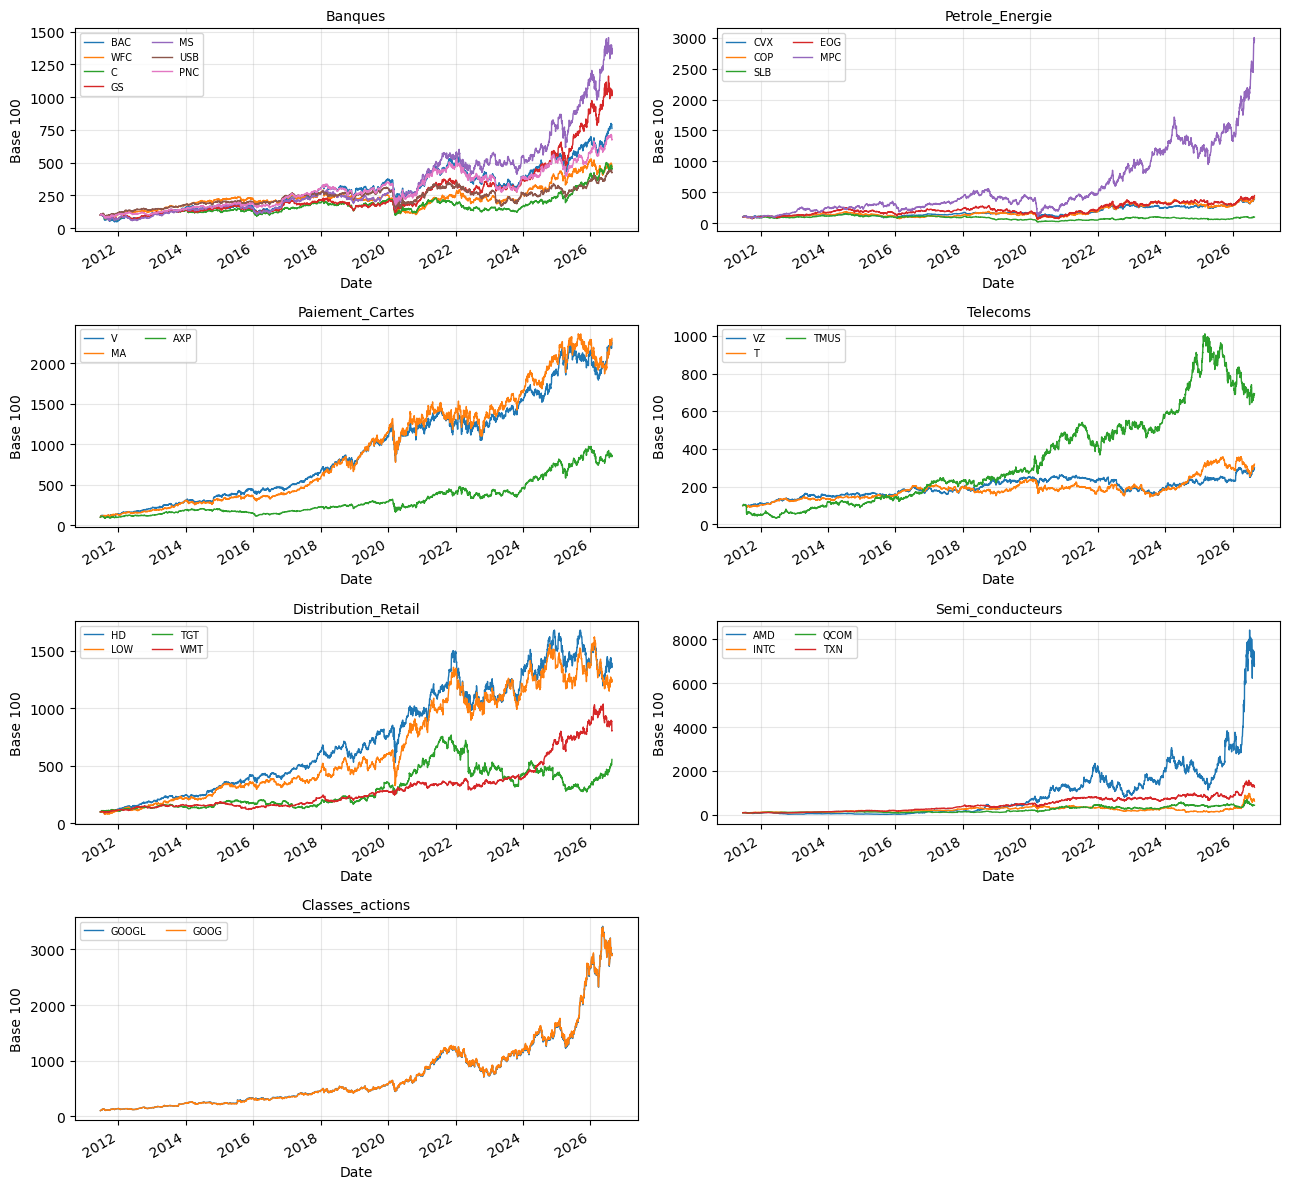

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(13, 12))
axes = axes.ravel()
for ax, (sec, tickers) in zip(axes, SECTORS.items()):
    cols = [t for t in tickers if t in adj_clean.columns]
    norm = adj_clean[cols] / adj_clean[cols].iloc[0] * 100
    norm.plot(ax=ax, lw=1); ax.set_title(sec, fontsize=10); ax.legend(fontsize=7, ncol=2)
    ax.set_ylabel("Base 100")
for ax in axes[len(SECTORS):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Sauvegarde

On archive les cours ajustés propres et la table des secteurs. Le notebook 06b (screener) chargera ces deux fichiers.


In [7]:
adj_clean.to_csv(os.path.join(DATA_DIR, "pairs_adj_close.csv"))

# Table secteur -> ne conserver que les titres réellement présents après nettoyage
sector_map = {t: sec for sec, ts in SECTORS.items() for t in ts if t in adj_clean.columns}
pd.Series(sector_map, name="secteur").rename_axis("ticker").to_csv(
    os.path.join(DATA_DIR, "pairs_sectors.csv"))

print("Fichiers écrits dans data/ :")
for f in ["pairs_prices_raw.parquet", "pairs_adj_close.csv", "pairs_sectors.csv"]:
    p = os.path.join(DATA_DIR, f)
    if os.path.exists(p):
        print(f"  - {f}  ({os.path.getsize(p)/1024:.0f} Ko)")
print("\nPrêt pour le notebook 06b — screener de paires cointégrées.")

Fichiers écrits dans data/ :
  - pairs_prices_raw.parquet  (4489 Ko)
  - pairs_adj_close.csv  (1949 Ko)
  - pairs_sectors.csv  (1 Ko)

Prêt pour le notebook 06b — screener de paires cointégrées.
